In [2]:
# Sam Brown
# sam_brown@mines.edu
# June 26 2025
# Goal: Procude high quality visualizations for meeting and expore long term data set preprocessed

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

import sys
sys.path.append("/Users/sambrown04/Documents/SURF/whillans-surf/notebooks/SURF")

df = pd.read_csv("/Users/sambrown04/Documents/SURF/Preproc_data/10-18.csv")
df = df[1:] # Account for features that "look back"

# Just GZ
dfgz = pd.read_csv("/Users/sambrown04/Documents/SURF/Preproc_data/averages_events_2011-13.csv")
dfgz = dfgz[1:-1]

Ideas:
 - plots comparing features during high tide vs low tide events (slip-size, tide amplitudes, time_since)
 - something regarding the difference in events when the tide derivative is negative vs when it is positive.
 - Some plots showing differences in station standards
 - Some neural net LSTM architecture

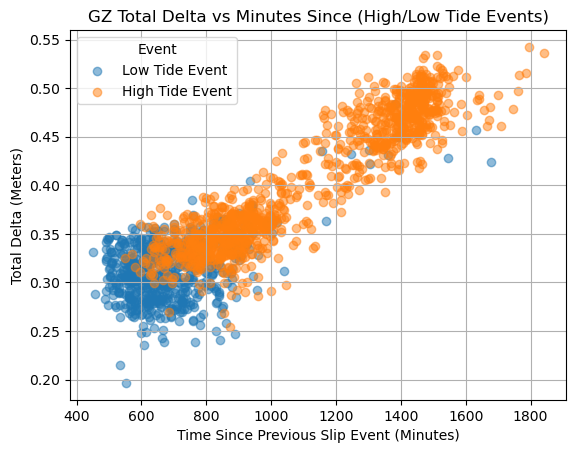

In [6]:
# High vs low tide plot for gz 11-13. Not very clean, capturing whether the low tide event was skipped would make it much better.

fig, ax = plt.subplots()

# colors and labels
colors = {0: 'tab:blue', 1: 'tab:orange'}
labels = {0: 'Low Tide Event', 1: 'High Tide Event'}

# Group and plot
for h_val, group in dfgz.groupby('h_event'):
    ax.scatter(group['mins_since'],
               group['total_delta'],
               c=colors[h_val],
               label=labels[h_val],
               alpha=0.5)

ax.set_xlabel('Time Since Previous Slip Event (Minutes)')
ax.set_ylabel('Total Delta (Meters)')
ax.set_title('GZ Total Delta vs Minutes Since (High/Low Tide Events)')
ax.legend(title='Event')
ax.grid(True)
plt.show()


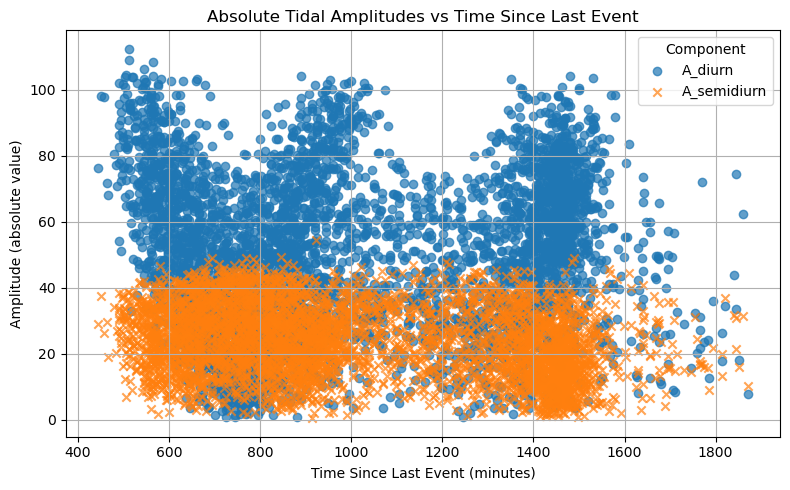

In [8]:


fig, ax = plt.subplots(figsize=(8, 5))

# Filter time range (Found to be best)
tmin, tmax = 400, 1900
df_filtered = df[(df['time_since'] >= tmin) & (df['time_since'] <= tmax)]

# Plot absolute amplitudes
ax.scatter(df_filtered['time_since'], np.abs(df_filtered['A_diurn']),
           label='A_diurn', alpha=0.7, marker='o')

ax.scatter(df_filtered['time_since'], np.abs(df_filtered['A_semidiurn']),
           label='A_semidiurn', alpha=0.7, marker='x')

# Labels and such
ax.set_xlabel('Time Since Last Event (minutes)')
ax.set_ylabel('Amplitude (absolute value)')
ax.set_title('Absolute Tidal Amplitudes vs Time Since Last Event')
ax.legend(title='Component')
ax.grid(True)
plt.tight_layout()
plt.show()

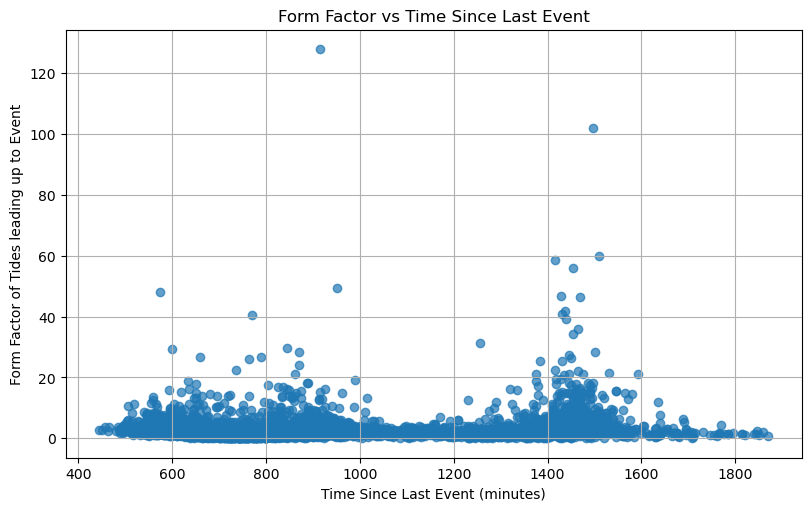

In [10]:
fig, ax = plt.subplots(figsize = (8,5), layout="constrained")
tmin, tmax = 400, 1900
df_filtered = df[(df['time_since'] >= tmin) & (df['time_since'] <= tmax)]

ax.scatter(df_filtered['time_since'], df_filtered['inter_form_Fac'], alpha = .7, marker = 'o')
ax.set_xlabel('Time Since Last Event (minutes)')
ax.set_ylabel('Form Fac of Tides leading up to Event')
ax.set_title('Form Fac vs Time Since Last Event')
ax.grid(True)
plt.show()

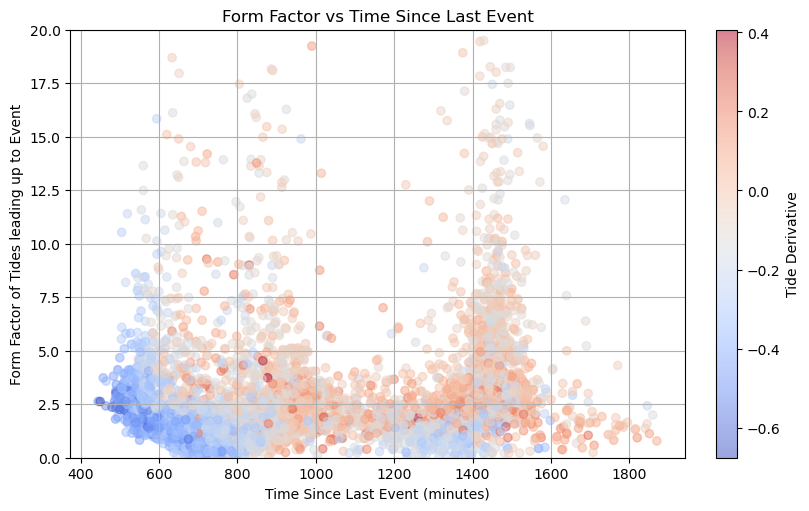

In [12]:
fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")
tmin, tmax = 400, 1900
df_filtered = df[(df['time_since'] >= tmin) & (df['time_since'] <= tmax)]

sc = ax.scatter(
    df_filtered['time_since'], 
    df_filtered['inter_form_Fac'], 
    c=df_filtered['tide_deriv'],   
    cmap='coolwarm',                
    alpha=0.5, 
    marker='o'
)

ax.set_xlabel('Time Since last Event (minutes)')
ax.set_ylabel('Form Fac of tides leading up to Event')
ax.set_title('Form Fac vs time Since Last Event')
ax.grid(True)
ax.set_ylim([0,20])

# Add a colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Tide Derivative')

plt.show()


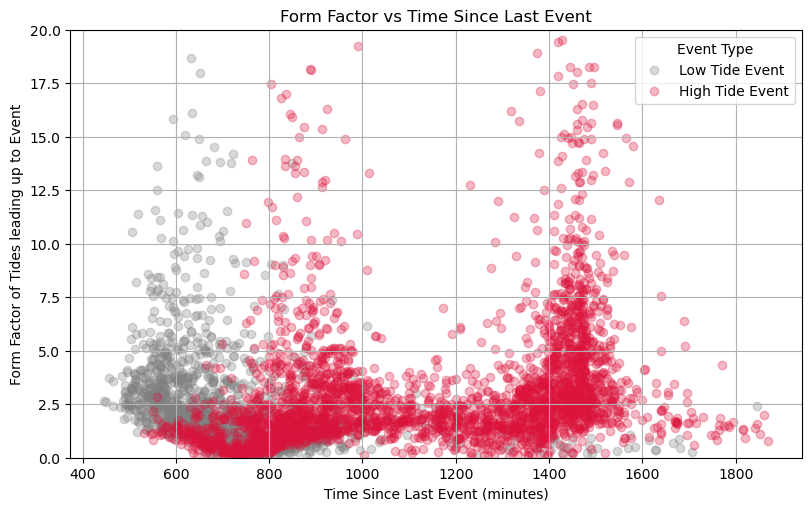

In [14]:
fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")
tmin, tmax = 400, 1900
df_filtered = df[(df['time_since'] >= tmin) & (df['time_since'] <= tmax)]

# plot each group seperately
colors = {0: 'gray', 1: 'crimson'}
labels = {0: 'Low Tide Event', 1: 'High Tide Event'}

for val in [0, 1]:
    subset = df_filtered[df_filtered['high_t_evt'] == val]
    ax.scatter(
        subset['time_since'],
        subset['inter_form_Fac'],
        color=colors[val],
        alpha=0.3,
        label=labels[val],
        marker='o'
    )

ax.set_xlabel('Time Since Last Event (minutes)')
ax.set_ylabel('Form Fact of Tides leading up to Event')
ax.set_title('Form Fac vs Time Since Last Event')
ax.grid(True)
ax.set_ylim([0, 20])
ax.legend(title='Event Type')

plt.show()

(0.0, 20.0)

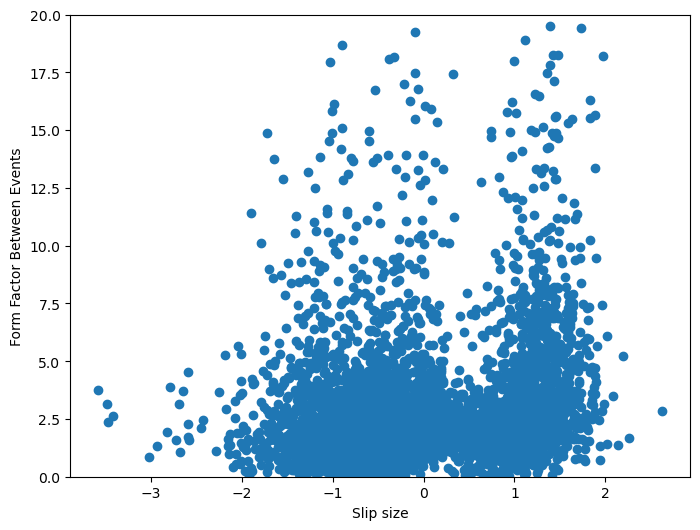

In [15]:
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(df['slip_size_standardized'], df['inter_form_Fac'])
ax.set_xlabel('Slip size')
ax.set_ylabel('Form Factor Between Events')
ax.set_ylim([0,20])

In [26]:
stations = pd.read_csv('../station_standards.csv')

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44],
 [Text(0, 0, 'la01'),
  Text(1, 0, 'la02'),
  Text(2, 0, 'la03'),
  Text(3, 0, 'la04'),
  Text(4, 0, 'la05'),
  Text(5, 0, 'la06'),
  Text(6, 0, 'la07'),
  Text(7, 0, 'la08'),
  Text(8, 0, 'la09'),
  Text(9, 0, 'la10'),
  Text(10, 0, 'la11'),
  Text(11, 0, 'la12'),
  Text(12, 0, 'la13'),
  Text(13, 0, 'la14'),
  Text(14, 0, 'la15'),
  Text(15, 0, 'la16'),
  Text(16, 0, 'la17'),
  Text(17, 0, 'la18'),
  Text(18, 0, 'gz01'),
  Text(19, 0, 'gz02'),
  Text(20, 0, 'gz03'),
  Text(21, 0, 'gz04'),
  Text(22, 0, 'gz05'),
  Text(23, 0, 'gz06'),
  Text(24, 0, 'gz07'),
  Text(25, 0, 'gz08'),
  Text(26, 0, 'gz09'),
  Text(27, 0, 'gz10'),
  Text(28, 0, 'gz11'),
  Text(29, 0, 'gz12'),
  Text(30, 0, 'gz13'),
  Text(31, 0, 'gz14'),
  Text(32, 0,

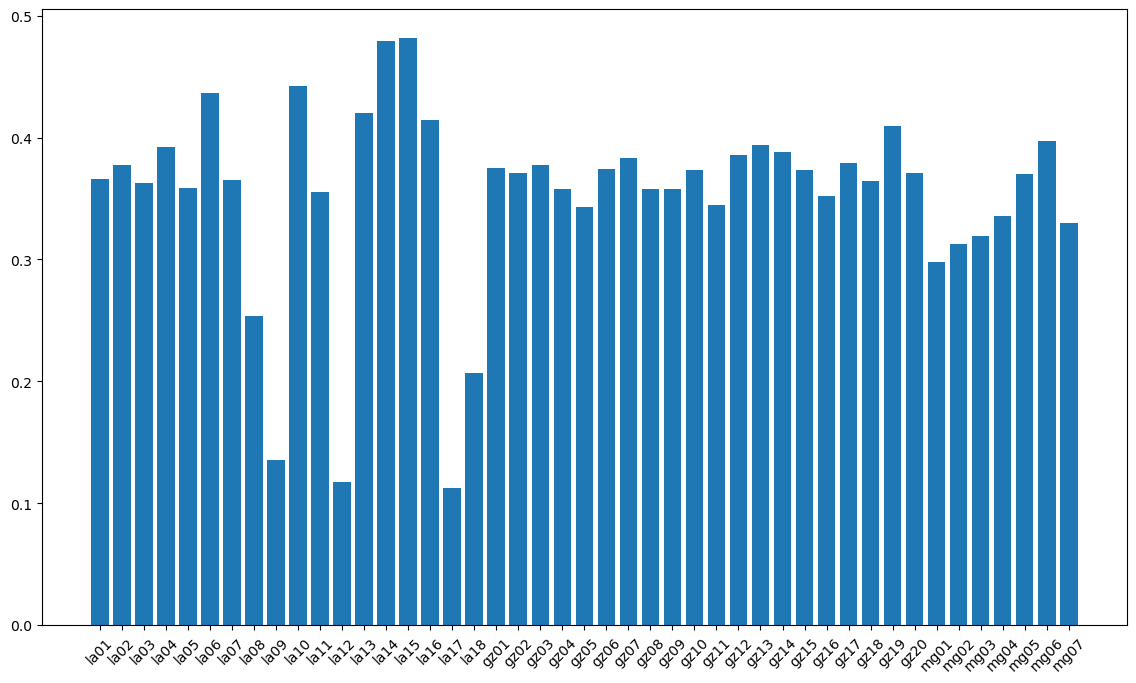

In [30]:
fig,ax = plt.subplots(figsize = (14,8))

ax.bar(stations['Station'], stations['slip_size'])
plt.xticks(rotation=45)

In [47]:
# Taking absolute value 
df['A_diurn_abs'] = df['A_diurn'].abs()
df['A_semidiurn_abs'] = df['A_semidiurn'].abs()

# new column for tide_deriv sign
df['tide_deriv_sign'] = df['tide_deriv'].apply(lambda x: 'Positive' if x > 0 else 'Negative')

# Group and compute mean amplitudes
mean_amps = df.groupby('tide_deriv_sign')[['A_diurn_abs', 'A_semidiurn_abs']].mean()
print(mean_amps)
mean_amps.columns = ['Diurnal Amplitude', 'Semi-diurnal Amplitude']

                 A_diurn_abs  A_semidiurn_abs
tide_deriv_sign                              
Negative           47.884840        23.890108
Positive           60.357255        22.864837


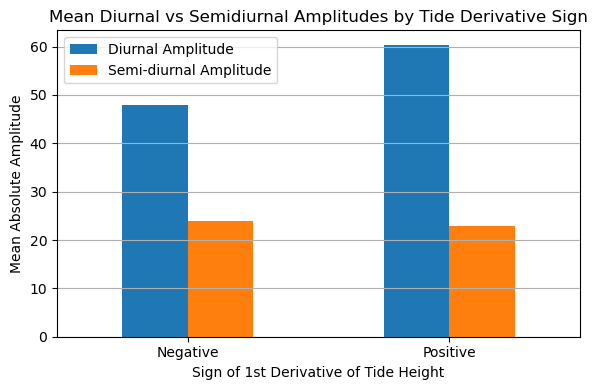

In [63]:

mean_amps.plot(kind='bar', figsize=(6, 4))
plt.title('Mean Diurnal vs Semidiurnal Amplitudes by Tide Derivative Sign')
plt.ylabel('Mean Absolute Amplitude')
plt.xlabel("Sign of 1st Derivative of Tide Height")
plt.xticks(rotation=0)
plt.grid(True, axis='y')
mean_amps.columns = ['Diurnal Amplitude', 'Semi-diurnal Amplitude']
plt.tight_layout()
plt.show()

In [37]:
# Calculate 
diurn_rising = mean_amps.loc['Positive', 'Diurnal Amplitude']

# Access mean diurnal amplitude for falling tides
diurn_falling = mean_amps.loc['Negative', 'Diurnal Amplitude']

# Same for semi-diurnal
semi_rising = mean_amps.loc['Positive', 'Semi-diurnal Amplitude']
semi_falling = mean_amps.loc['Negative', 'Semi-diurnal Amplitude']

In [41]:
print(diurn_rising, diurn_falling, semi_rising, semi_falling)

60.357255246691636 47.88484031092521 22.86483734302967 23.89010811791274


In [49]:
# We can't assume equal variance so we will use welch's t-test

# Split data based on sign
rising_diurn = df[df['tide_deriv_sign'] == 'Positive']['A_diurn_abs']
falling_diurn = df[df['tide_deriv_sign'] == 'Negative']['A_diurn_abs']

In [59]:
# t-test
t_stat, p_val = ttest_ind(rising_diurn, falling_diurn, equal_var=False)

# Print results
print(f"Rising tide count: {len(rising_diurn)}")
print(f"Falling tide count: {len(falling_diurn)}")
print(f"Mean (Rising): {rising_diurn.mean():.2f}")
print(f"Mean (Falling): {falling_diurn.mean():.2f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.2e}")  # scientific notation

Rising tide count: 962
Falling tide count: 3613
Mean (Rising): 60.36
Mean (Falling): 47.88
T-statistic: 14.5579
P-value: 5.77e-45


In [61]:
# Compute means and standard deviations
mean1, mean2 = rising_diurn.mean(), falling_diurn.mean()
std1, std2 = rising_diurn.std(), falling_diurn.std()
n1, n2 = len(rising_diurn), len(falling_diurn)

# Pooled standard deviation
pooled_std = np.sqrt(((std1**2) + (std2**2)) / 2)

# Cohen's d
cohen_d = (mean1 - mean2) / pooled_std
print(f"Cohen's d: {cohen_d:.2f}")

Cohen's d: 0.53
